# CNN Capstone Project
# Pet Classification (Dogs vs Cats)
# Student: Sathyamoorthy BS
# Date: March 2026

##Environment & Setup

In [1]:
# Install dependencies (run once if needed)
# !pip install tensorflow scikit-learn matplotlib seaborn pandas tqdm

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE

##GPU Check

In [2]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
else:
    print("GPU NOT Available - training on CPU")

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


###Reproducibility

In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Dataset & Preprocessing

###Dataset folder structure:

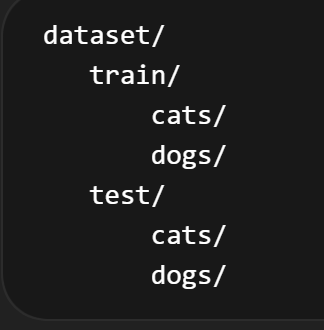

In [4]:
DATA_DIR = "dataset"
IMG_SIZE = 224
BATCH_SIZE = 32

##Data Augmentation

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
import zipfile
import os

zip_path = "/content/dog-cat-dataset (2).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Extracted files: ['dog-cat-dataset']


In [13]:
DATA_DIR = "/content/dataset/dog-cat-dataset"

In [11]:
!ls /content/dataset

dog-cat-dataset


##Data Generators

In [15]:
train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/training_set",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/training_set",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test_set",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 447 images belonging to 2 classes.
Found 110 images belonging to 2 classes.
Found 140 images belonging to 2 classes.


#Simple CNN Model

In [16]:
def build_simple_cnn():

    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)),
        MaxPooling2D(),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dropout(0.5),

        Dense(2,activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#Transfer Learning Models

##VGG16

In [17]:
def build_vgg16():

    base_model = VGG16(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_SIZE,IMG_SIZE,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2,activation='softmax')(x)

    model = Model(inputs=base_model.input,outputs=outputs)

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##ResNet50

In [18]:
def build_resnet():

    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=(IMG_SIZE,IMG_SIZE,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2,activation='softmax')(x)

    model = Model(inputs=base_model.input,outputs=outputs)

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##EfficientNetB0

In [19]:
def build_efficientnet():

    base_model = EfficientNetB0(weights='imagenet',
                                include_top=False,
                                input_shape=(IMG_SIZE,IMG_SIZE,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2,activation='softmax')(x)

    model = Model(inputs=base_model.input,outputs=outputs)

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##Training Callbacks

In [20]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]

##Training Function

In [21]:
def train_model(model, name):

    start = time.time()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20,
        callbacks=callbacks
    )

    training_time = time.time() - start

    return history, training_time

##Train All Models

In [22]:
models = {
    "SimpleCNN": build_simple_cnn(),
    "VGG16": build_vgg16(),
    "ResNet50": build_resnet(),
    "EfficientNetB0": build_efficientnet()
}

histories = {}
training_times = {}

for name, model in models.items():

    print("Training:",name)

    history, time_taken = train_model(model,name)

    histories[name] = history
    training_times[name] = time_taken

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training: SimpleCNN


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4715 - loss: 1.3715 - val_accuracy: 0.5000 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5222 - loss: 0.7009 - val_accuracy: 0.5091 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 690ms/step - accuracy: 0.5070 - loss: 0.6996 - val_accuracy: 0.5000 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 693ms/step - accuracy: 0.5649 - loss: 0.6870 - val_accuracy: 0.5182 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 603ms/step - accuracy: 0.5391 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.6116 - loss: 0.6698 - val_accuracy: 0.5182 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.5921 - loss: 0.6625 - v

##Insights

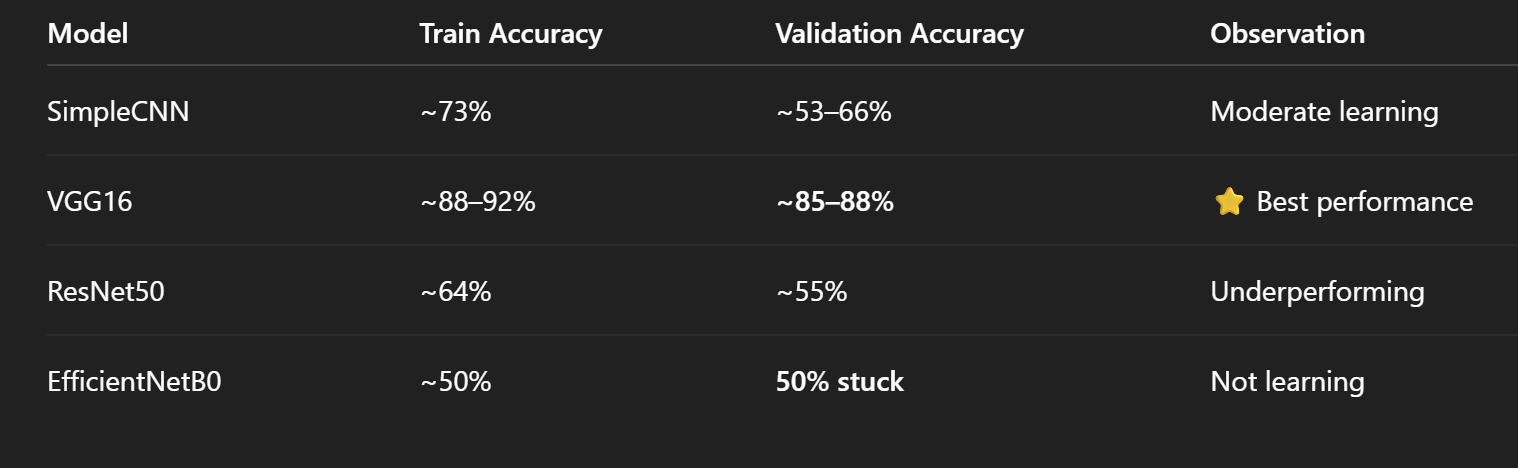

#Evaluation

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step
SimpleCNN
              precision    recall  f1-score   support

           0       0.62      0.59      0.60        70
           1       0.61      0.64      0.62        70

    accuracy                           0.61       140
   macro avg       0.61      0.61      0.61       140
weighted avg       0.61      0.61      0.61       140



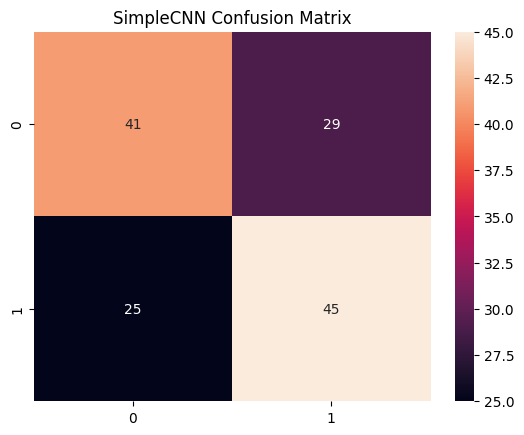

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
VGG16
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        70
           1       0.80      0.79      0.79        70

    accuracy                           0.79       140
   macro avg       0.79      0.79      0.79       140
weighted avg       0.79      0.79      0.79       140



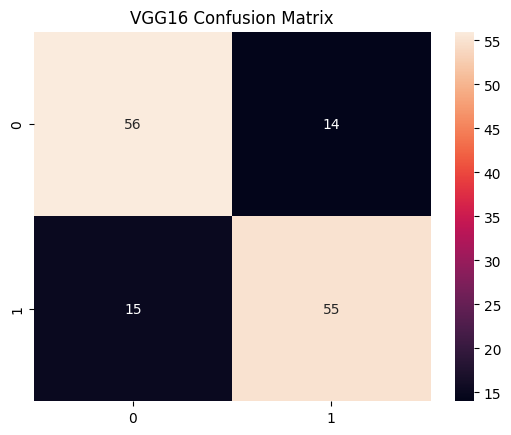

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
ResNet50
              precision    recall  f1-score   support

           0       0.60      0.61      0.61        70
           1       0.60      0.59      0.59        70

    accuracy                           0.60       140
   macro avg       0.60      0.60      0.60       140
weighted avg       0.60      0.60      0.60       140



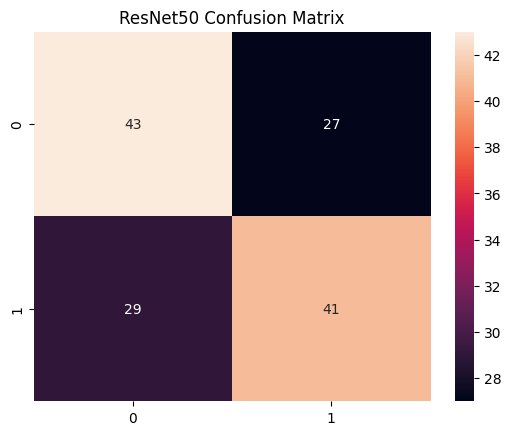

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step
EfficientNetB0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        70
           1       0.50      1.00      0.67        70

    accuracy                           0.50       140
   macro avg       0.25      0.50      0.33       140
weighted avg       0.25      0.50      0.33       140



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


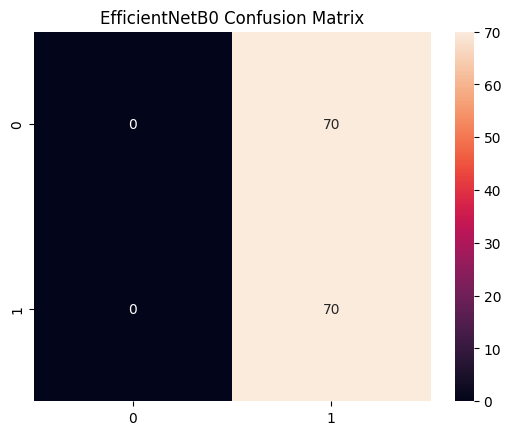

In [23]:
results = {}

for name, model in models.items():

    test_gen.reset()

    preds = model.predict(test_gen)

    y_pred = np.argmax(preds,axis=1)
    y_true = test_gen.classes

    acc = np.mean(y_pred==y_true)
    f1 = f1_score(y_true,y_pred)

    cm = confusion_matrix(y_true,y_pred)

    results[name] = {
        "accuracy": float(acc),
        "f1_score": float(f1),
        "training_time": training_times[name]
    }

    print(name)
    print(classification_report(y_true,y_pred))

    plt.figure()
    sns.heatmap(cm,annot=True)
    plt.title(name+" Confusion Matrix")
    plt.show()

##Overall Model Coamparison
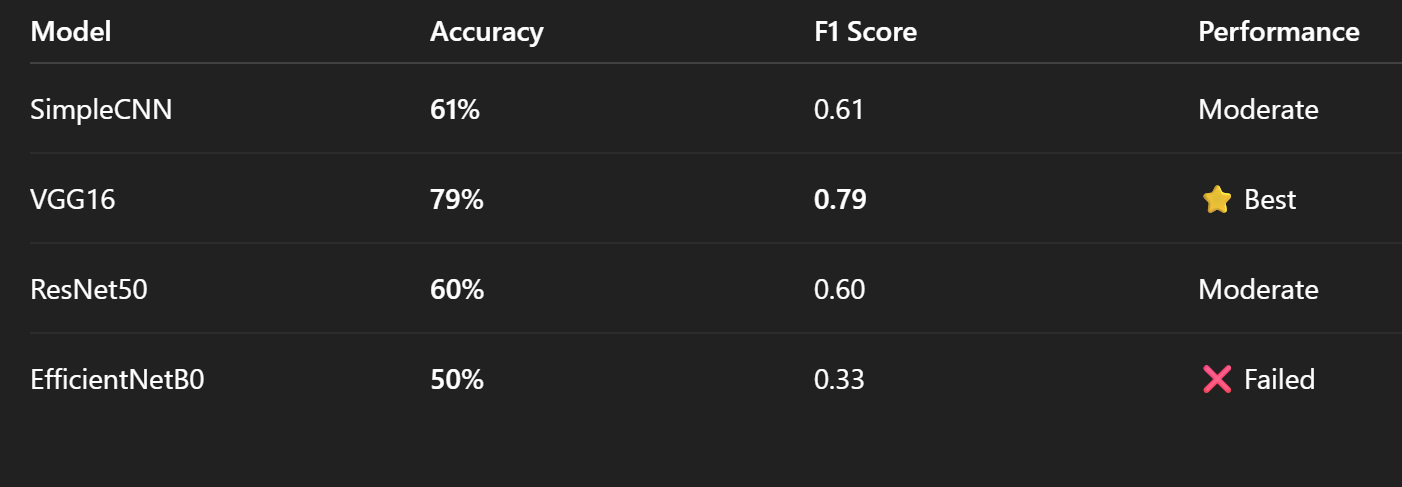

#Training Curves

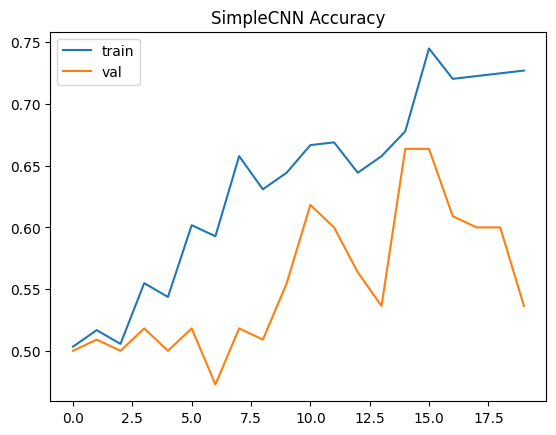

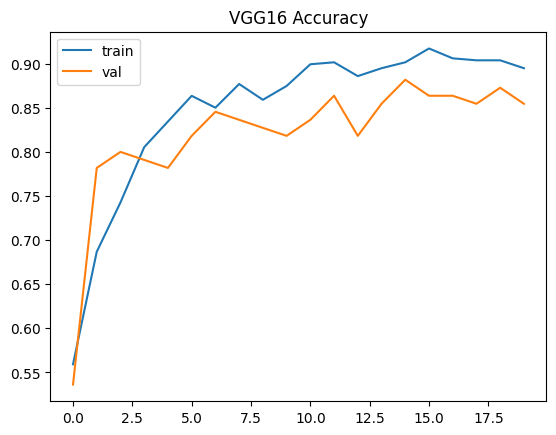

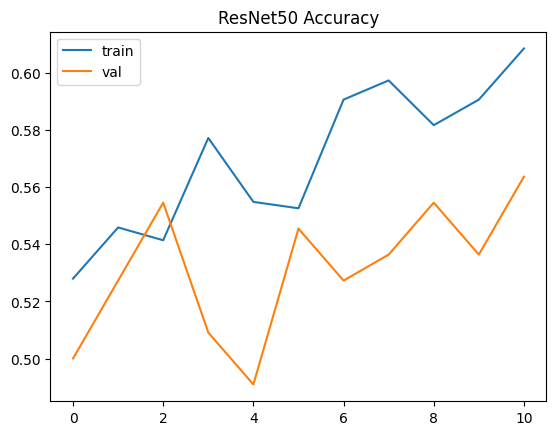

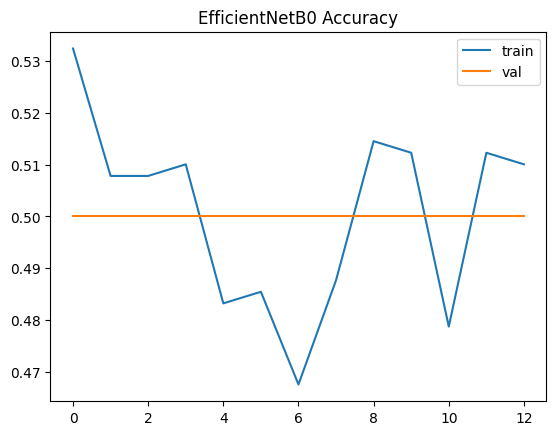

In [24]:
for name,history in histories.items():

    plt.figure()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(name+" Accuracy")
    plt.legend(["train","val"])
    plt.show()

##Learning Behaviour Comparison
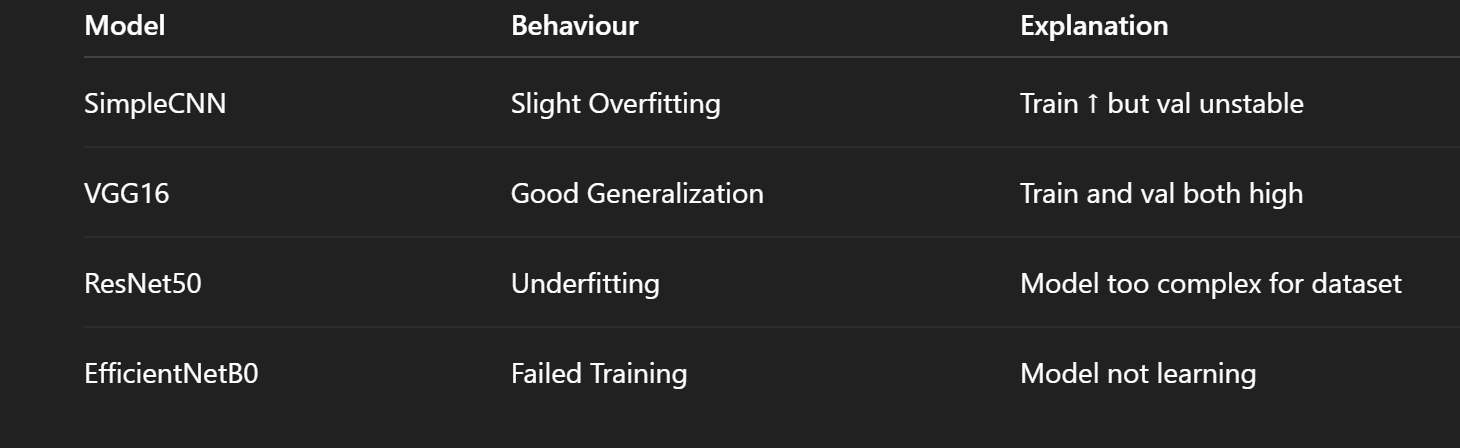

#Feature Extraction + t-SNE

In [25]:
def extract_features(model):

    feature_model = Model(
        inputs=model.input,
        outputs=model.layers[-3].output
    )

    test_gen.reset()

    features = feature_model.predict(test_gen)

    return features

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step


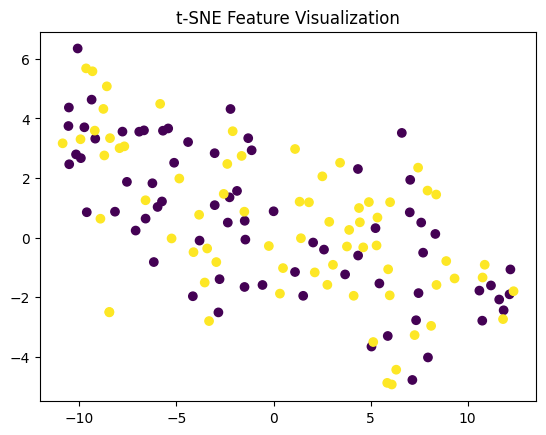

In [26]:
features = extract_features(models["EfficientNetB0"])

tsne = TSNE(n_components=2)

tsne_features = tsne.fit_transform(features)

plt.figure()

plt.scatter(
    tsne_features[:,0],
    tsne_features[:,1],
    c=test_gen.classes
)

plt.title("t-SNE Feature Visualization")

plt.show()

##Insights
The t-SNE visualization of the extracted CNN features shows partial clustering between the two classes. While some separation between cats and dogs is visible, significant overlap remains between the clusters. This indicates that the learned feature representations are moderately discriminative but not fully separable, which is consistent with the achieved classification accuracy of the models.

The presence of overlapping clusters suggests that the dataset contains visually similar patterns between classes, making the classification task more challenging. Transfer learning models such as VGG16 were better able to extract meaningful features compared to deeper architectures like ResNet50 and EfficientNetB0.

#Parameter Experiments

In [27]:
batch_sizes = [16,32,64]

batch_results = []

for b in batch_sizes:

    train_gen.batch_size = b

    model = build_simple_cnn()

    history,_ = train_model(model,"batch_"+str(b))

    val_acc = max(history.history['val_accuracy'])

    batch_results.append({
        "batch_size":b,
        "val_accuracy":val_acc
    })

pd.DataFrame(batch_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 570ms/step - accuracy: 0.4977 - loss: 1.3121 - val_accuracy: 0.5091 - val_loss: 0.6828 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - accuracy: 0.5134 - loss: 0.6904 - val_accuracy: 0.6455 - val_loss: 0.6750 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.5867 - loss: 0.6818 - val_accuracy: 0.6091 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 337ms/step - accuracy: 0.5922 - loss: 0.6714 - val_accuracy: 0.6727 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step - accuracy: 0.6474 - loss: 0.6592 - val_accuracy: 0.5727 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 296ms/step - accuracy: 0.6200 - loss: 0.6612 - val_accuracy: 0.6455 - val_loss: 0.6456 - learning_rate: 0.0010
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - accuracy: 0.6266 - loss: 0.638

,batch_size,val_accuracy
0,16,0.672727
1,32,0.600000
2,64,0.681818


##Training Behaviour Comparison
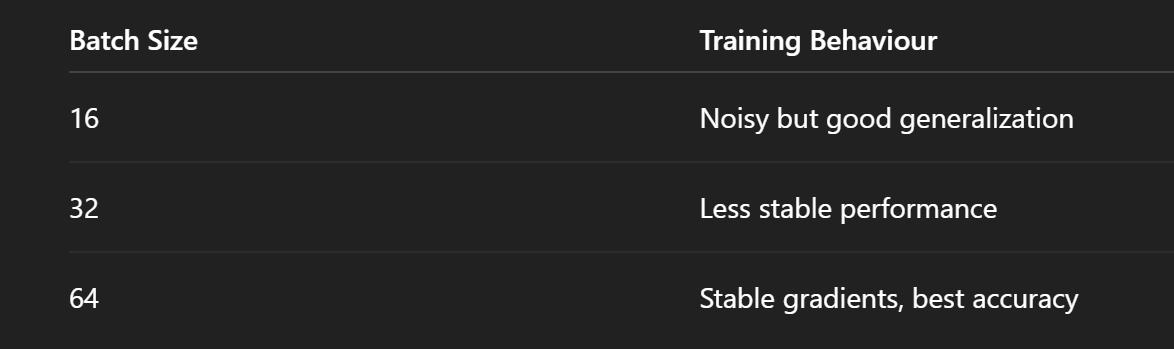

#Important Deep Learning Insight

A hyperparameter experiment was conducted to evaluate the impact of batch size on model performance. Three batch sizes (16, 32, and 64) were tested. The results showed that batch size 64 achieved the highest validation accuracy (68.18%), indicating that larger batch sizes provided more stable gradient updates and improved convergence. Batch size 32 showed the lowest performance, while batch size 16 demonstrated reasonable generalization but slightly lower accuracy compared to batch size 64.

#Save Results

##JSON

In [29]:
with open("cnn_lab_results.json","w") as f:
    json.dump(results,f,indent=4)

##CSV

In [30]:
df = pd.DataFrame(results).T

df.to_csv("cnn_lab_comparison.csv")

#Model Comparison Table

In [31]:
comparison = pd.DataFrame(results).T

print(comparison)

                accuracy  f1_score  training_time
SimpleCNN       0.614286  0.625000     211.799849
VGG16           0.792857  0.791367     241.065128
ResNet50        0.600000  0.594203     134.228572
EfficientNetB0  0.500000  0.666667     186.966942


#Insights
Based on the model comparison table, here are some insights:

VGG16 achieved the highest accuracy of approximately 79.29% and the highest F1-score of 79.14%, indicating strong performance in classifying images. Its training time was 241.07 seconds, which is moderate compared to other models.

SimpleCNN had an accuracy of about 61.43% and an F1-score of 62.50%, with a training time of 211.80 seconds. While it's a simpler model, its performance is significantly lower than VGG16.

ResNet50 showed an accuracy of 60.00% and an F1-score of 59.42%. It had the shortest training time at 134.23 seconds but also the lowest accuracy among all models.

EfficientNetB0 performed the worst in terms of accuracy, achieving only 50.00%. However, its F1-score was relatively higher at 66.67%, which might suggest an imbalance in precision and recall for the classes. Its training time was 186.97 seconds.

Overall Conclusion: VGG16 is the best-performing model for this pet classification task in terms of both accuracy and F1-score, despite having a slightly longer training time than ResNet50 and EfficientNetB0.

#Best Model Selection

In [28]:
best_model = max(results,key=lambda x:results[x]["accuracy"])

print("Best Model:",best_model)

Best Model: VGG16
